In [1]:
# ==============================
# 02. Exploratory Data Analysis
# Ecommerce Customer Behavior Analysis
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries loaded!")

Libraries loaded!


In [2]:
# Load Cleaned Data
df = pd.read_csv('../data/processed/customer_shopping_cleaned.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (3900, 21)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Age_Group,High_Value_Customer,Used_Any_Discount
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,Senior (50+),No,Yes
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Yes,Express,Yes,Yes,2,Cash,Fortnightly,Young (18-24),No,Yes
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,Senior (50+),No,Yes
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,Young (18-24),Yes,Yes
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,Middle Age (35-49),Yes,Yes


In [3]:
print("="*60)
print("KEY BUSINESS METRICS")
print("="*60)

total_customers = df['Customer ID'].nunique()
total_revenue = df['Purchase Amount (USD)'].sum()
avg_order_value = df['Purchase Amount (USD)'].mean()
avg_rating = df['Review Rating'].mean()
subscription_rate = (df['Subscription Status'] == 'Yes').mean() * 100
discount_usage = (df['Discount Applied'] == 'Yes').mean() * 100

print(f"Total Unique Customers     : {total_customers:,}")
print(f"Total Revenue              : ${total_revenue:,.2f}")
print(f"Average Order Value (AOV)  : ${avg_order_value:.2f}")
print(f"Average Review Rating      : {avg_rating:.2f}")
print(f"Subscription Rate          : {subscription_rate:.1f}%")
print(f"Discount Usage Rate        : {discount_usage:.1f}%")

KEY BUSINESS METRICS
Total Unique Customers     : 3,900
Total Revenue              : $233,081.00
Average Order Value (AOV)  : $59.76
Average Review Rating      : 3.75
Subscription Rate          : 27.0%
Discount Usage Rate        : 43.0%


In [4]:
# Category wise Revenue & Orders
category_analysis = df.groupby('Category').agg(
    Total_Orders=('Customer ID', 'count'),
    Total_Revenue=('Purchase Amount (USD)', 'sum'),
    Avg_Order_Value=('Purchase Amount (USD)', 'mean'),
    Avg_Rating=('Review Rating', 'mean')
).sort_values('Total_Revenue', ascending=False)

category_analysis['Revenue_Share_%'] = (category_analysis['Total_Revenue'] / category_analysis['Total_Revenue'].sum()) * 100

print("Category Performance:")
display(category_analysis.round(2))

Category Performance:


,Total_Orders,Total_Revenue,Avg_Order_Value,Avg_Rating,Revenue_Share_%
Category,,,,,
Clothing,1737,104264,60.03,3.72,44.73
Accessories,1240,74200,59.84,3.77,31.83
Footwear,599,36093,60.26,3.79,15.49
Outerwear,324,18524,57.17,3.75,7.95


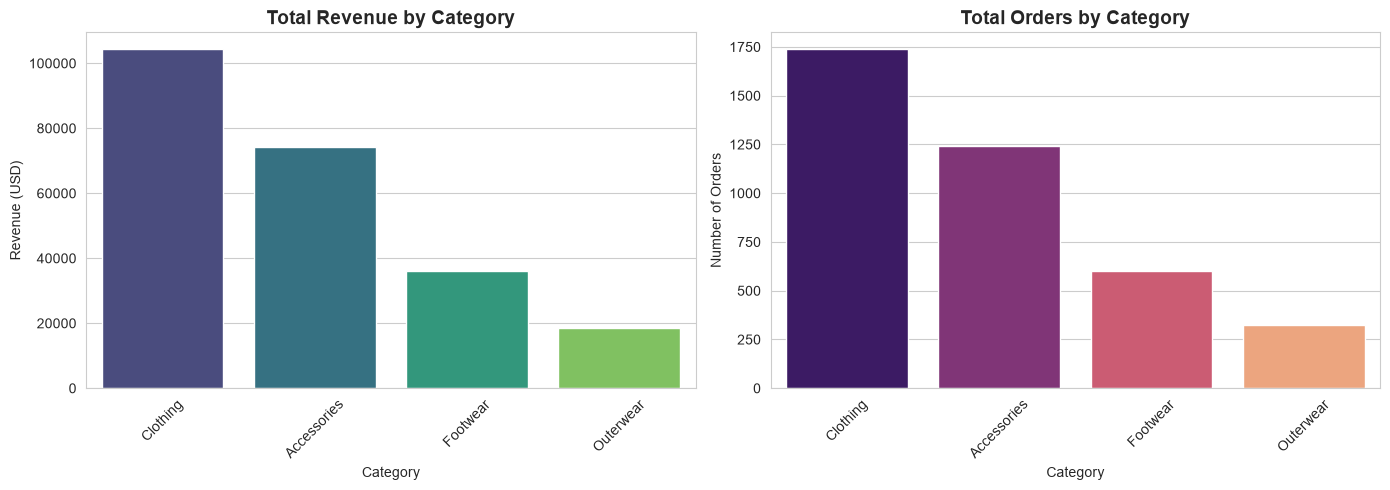

In [5]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue by Category
sns.barplot(data=category_analysis.reset_index(), x='Category', y='Total_Revenue', 
            palette='viridis', ax=axes[0])
axes[0].set_title('Total Revenue by Category', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Revenue (USD)')
axes[0].tick_params(axis='x', rotation=45)

# Orders by Category
sns.barplot(data=category_analysis.reset_index(), x='Category', y='Total_Orders', 
            palette='magma', ax=axes[1])
axes[1].set_title('Total Orders by Category', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [6]:
gender_analysis = df.groupby('Gender').agg(
    Customers=('Customer ID', 'nunique'),
    Total_Revenue=('Purchase Amount (USD)', 'sum'),
    Avg_Spend=('Purchase Amount (USD)', 'mean'),
    Avg_Previous_Purchases=('Previous Purchases', 'mean')
)

gender_analysis['Revenue_Share_%'] = (gender_analysis['Total_Revenue'] / gender_analysis['Total_Revenue'].sum()) * 100
print("Gender Analysis:")
display(gender_analysis.round(2))

Gender Analysis:


,Customers,Total_Revenue,Avg_Spend,Avg_Previous_Purchases,Revenue_Share_%
Gender,,,,,
Female,1248,75191,60.25,24.60,32.26
Male,2652,157890,59.54,25.71,67.74


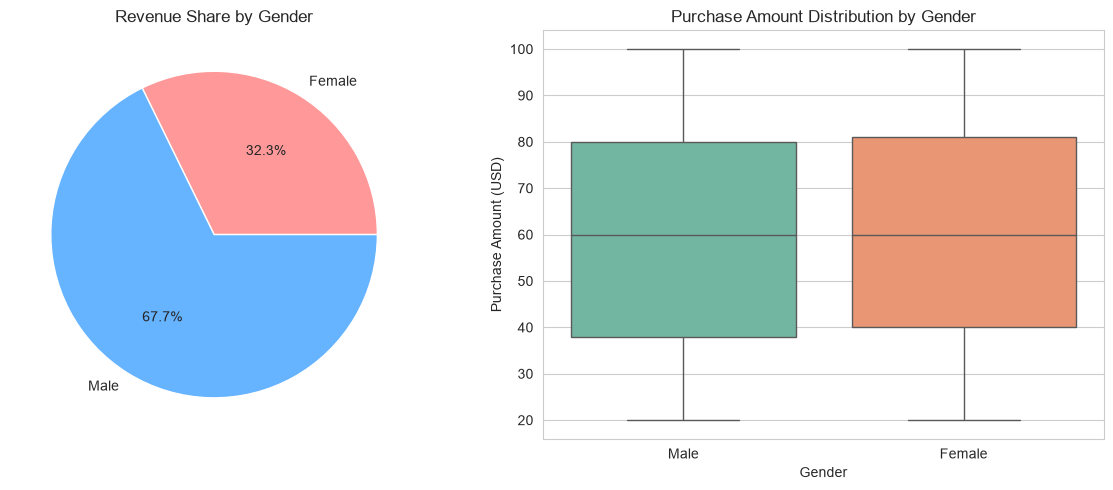

In [7]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.groupby('Gender')['Purchase Amount (USD)'].sum().plot(
    kind='pie', autopct='%1.1f%%', ax=axes[0], colors=['#ff9999','#66b3ff']
)
axes[0].set_title('Revenue Share by Gender')
axes[0].set_ylabel('')

sns.boxplot(data=df, x='Gender', y='Purchase Amount (USD)', palette='Set2', ax=axes[1])
axes[1].set_title('Purchase Amount Distribution by Gender')

plt.tight_layout()
plt.show()

In [8]:
season_analysis = df.groupby('Season').agg(
    Orders=('Customer ID', 'count'),
    Revenue=('Purchase Amount (USD)', 'sum'),
    Avg_AOV=('Purchase Amount (USD)', 'mean')
).sort_values('Revenue', ascending=False)

print("Seasonal Performance:")
display(season_analysis.round(2))

Seasonal Performance:


,Orders,Revenue,Avg_AOV
Season,,,
Fall,975,60018,61.56
Spring,999,58679,58.74
Winter,971,58607,60.36
Summer,955,55777,58.41


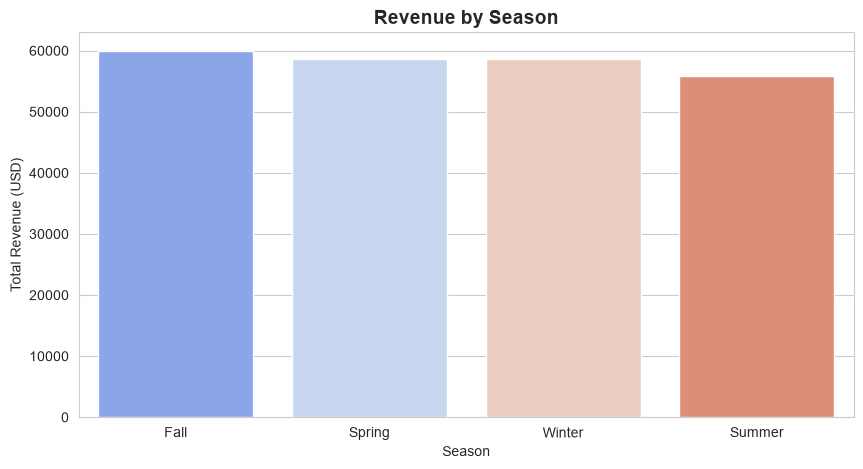

In [9]:
plt.figure(figsize=(10, 5))
sns.barplot(data=season_analysis.reset_index(), x='Season', y='Revenue', palette='coolwarm')
plt.title('Revenue by Season', fontsize=14, fontweight='bold')
plt.ylabel('Total Revenue (USD)')
plt.show()

In [10]:
subscription_analysis = df.groupby('Subscription Status').agg(
    Customers=('Customer ID', 'nunique'),
    Total_Revenue=('Purchase Amount (USD)', 'sum'),
    Avg_Spend=('Purchase Amount (USD)', 'mean'),
    Avg_Previous_Purchases=('Previous Purchases', 'mean'),
    Avg_Rating=('Review Rating', 'mean')
)

print("Subscription vs Non-Subscription:")
display(subscription_analysis.round(2))

Subscription vs Non-Subscription:


,Customers,Total_Revenue,Avg_Spend,Avg_Previous_Purchases,Avg_Rating
Subscription Status,,,,,
No,2847,170436,59.87,25.08,3.75
Yes,1053,62645,59.49,26.08,3.75


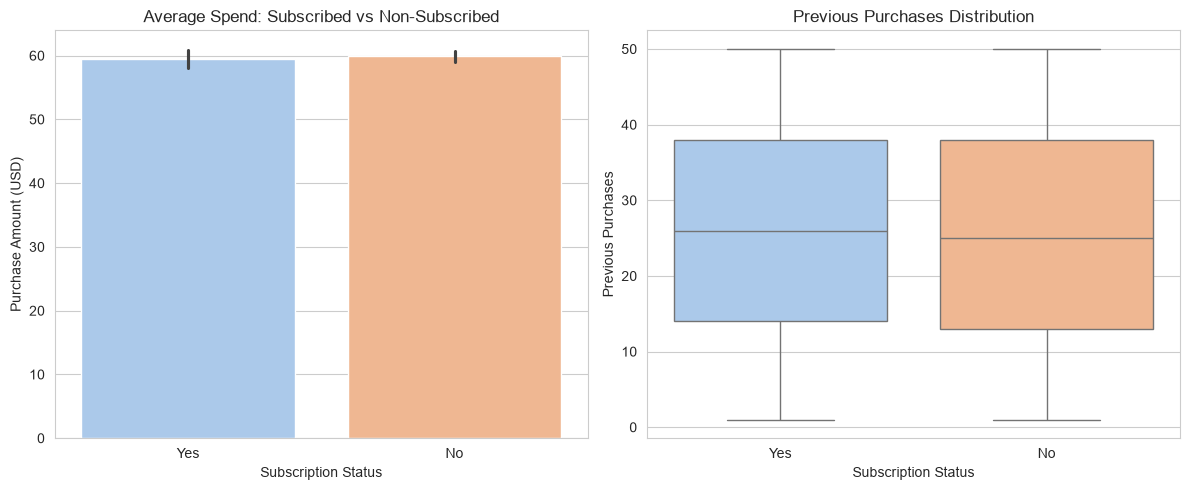

In [11]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=df, x='Subscription Status', y='Purchase Amount (USD)', 
            estimator=np.mean, palette='pastel', ax=axes[0])
axes[0].set_title('Average Spend: Subscribed vs Non-Subscribed')

sns.boxplot(data=df, x='Subscription Status', y='Previous Purchases', 
            palette='pastel', ax=axes[1])
axes[1].set_title('Previous Purchases Distribution')

plt.tight_layout()
plt.show()

In [12]:
discount_analysis = df.groupby('Discount Applied').agg(
    Orders=('Customer ID', 'count'),
    Total_Revenue=('Purchase Amount (USD)', 'sum'),
    Avg_AOV=('Purchase Amount (USD)', 'mean')
)

print("Discount Applied Impact:")
display(discount_analysis.round(2))

print("\n" + "="*50)
promo_analysis = df.groupby('Promo Code Used').agg(
    Orders=('Customer ID', 'count'),
    Total_Revenue=('Purchase Amount (USD)', 'sum'),
    Avg_AOV=('Purchase Amount (USD)', 'mean')
)
print("Promo Code Impact:")
display(promo_analysis.round(2))

Discount Applied Impact:


,Orders,Total_Revenue,Avg_AOV
Discount Applied,,,
No,2223,133670,60.13
Yes,1677,99411,59.28



Promo Code Impact:


,Orders,Total_Revenue,Avg_AOV
Promo Code Used,,,
No,2223,133670,60.13
Yes,1677,99411,59.28


In [13]:
age_group_analysis = df.groupby('Age_Group').agg(
    Customers=('Customer ID', 'nunique'),
    Revenue=('Purchase Amount (USD)', 'sum'),
    Avg_Spend=('Purchase Amount (USD)', 'mean'),
    Avg_Previous=('Previous Purchases', 'mean')
).sort_values('Revenue', ascending=False)

print("Age Group Performance:")
display(age_group_analysis.round(2))

Age Group Performance:


,Customers,Revenue,Avg_Spend,Avg_Previous
Age_Group,,,,
Senior (50+),1559,93410,59.92,26.14
Middle Age (35-49),1100,65013,59.10,24.96
Adult (25-34),755,45400,60.13,25.04
Young (18-24),486,29258,60.20,24.22


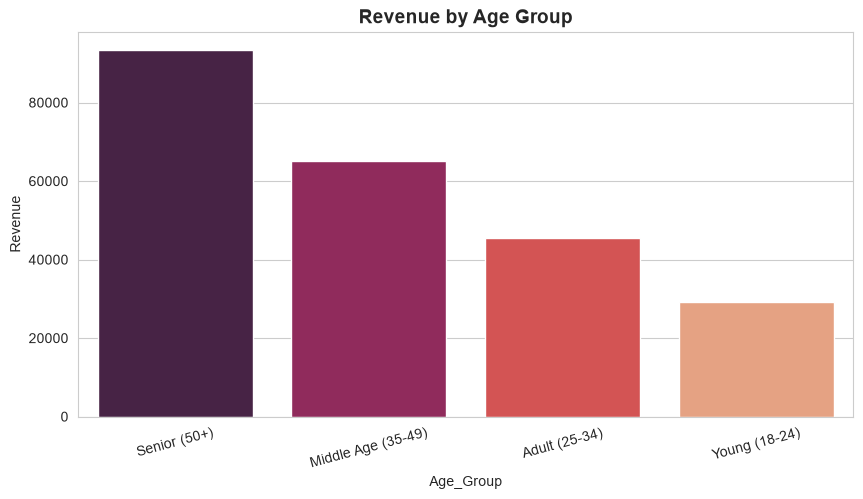

In [14]:
plt.figure(figsize=(10, 5))
sns.barplot(data=age_group_analysis.reset_index(), x='Age_Group', y='Revenue', palette='rocket')
plt.title('Revenue by Age Group', fontsize=14, fontweight='bold')
plt.xticks(rotation=15)
plt.show()

In [15]:
hv_analysis = df.groupby('High_Value_Customer').agg(
    Count=('Customer ID', 'count'),
    Total_Revenue=('Purchase Amount (USD)', 'sum'),
    Avg_Spend=('Purchase Amount (USD)', 'mean')
)

hv_analysis['Revenue_Share_%'] = (hv_analysis['Total_Revenue'] / hv_analysis['Total_Revenue'].sum()) * 100
print("High Value Customer Impact:")
display(hv_analysis.round(2))

High Value Customer Impact:


,Count,Total_Revenue,Avg_Spend,Revenue_Share_%
High_Value_Customer,,,,
No,1679,82133,48.92,35.24
Yes,2221,150948,67.96,64.76


In [16]:
top_locations = df.groupby('Location').agg(
    Orders=('Customer ID', 'count'),
    Revenue=('Purchase Amount (USD)', 'sum')
).sort_values('Revenue', ascending=False).head(10)

print("Top 10 Locations by Revenue:")
display(top_locations)

Top 10 Locations by Revenue:


,Orders,Revenue
Location,,
Montana,96,5784
Illinois,92,5617
California,95,5605
Idaho,93,5587
Nevada,87,5514
Alabama,89,5261
New York,87,5257
North Dakota,83,5220
West Virginia,81,5174


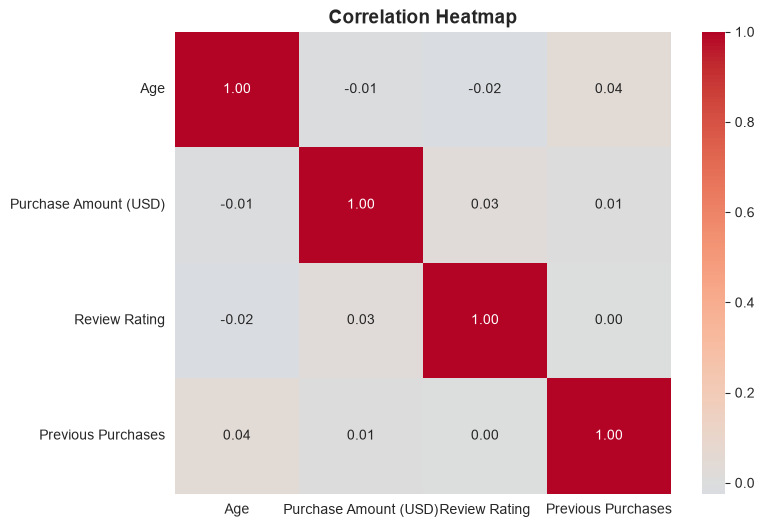

In [17]:
numerical_cols = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']
plt.figure(figsize=(8, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()

In [18]:
print("""
============================================================
KEY BUSINESS INSIGHTS (Write your observations here)
============================================================

1. Category Performance:
   - 

2. Gender Insight:
   - 

3. Subscription Impact:
   - 

4. Seasonal Trend:
   - 

5. Discount Effectiveness:
   - 

6. High Value Customers:
   - 

7. Recommendation:
   - 
""")


KEY BUSINESS INSIGHTS (Write your observations here)

1. Category Performance:
   - 

2. Gender Insight:
   - 

3. Subscription Impact:
   - 

4. Seasonal Trend:
   - 

5. Discount Effectiveness:
   - 

6. High Value Customers:
   - 

7. Recommendation:
   - 

